In [1]:
from dataset_creation import build_dataset
from pathlib import Path
from sklearn.utils import shuffle

base_dir = Path().cwd()
train_dir = base_dir / "dataset" / "Train_preprocessed"
test_dir = base_dir / "dataset" / "Test_preprocessed"

X_train, y_train = build_dataset(train_dir)
X_test, y_test = build_dataset(test_dir)

X_train, y_train = shuffle(X_train, y_train, random_state=42)
X_test, y_test = shuffle(X_test, y_test, random_state=42)

X_train

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.00392157, 0.00392157,
        0.00392157],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]], shape=(5600, 50176), dtype=float32)

In [2]:
import numpy as np

np.unique(y_train, return_counts=True)

(array([0, 1, 2, 3], dtype=int8), array([1400, 1400, 1400, 1400]))

In [3]:
# from sklearn.random_projection import SparseRandomProjection

# sparse_rnd_proj = SparseRandomProjection(random_state=42, n_components=20000)
# X_train_reduced = sparse_rnd_proj.fit_transform(X_train)
# X_train_reduced

In [4]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

def plot_cm(y_test, y_pred, model_name):
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=target_names, yticklabels=target_names)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'{model_name} Brain Tumor CLF Confusion Matrix')
    plt.show()

c:\Users\Adisa Teslim\OneDrive\Documents\Programming Journey\Machine Learning\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Classification Report
{'glioma': {'precision': 0.7329376854599406, 'recall': 0.6175, 'f1-score': 0.6702849389416553, 'support': 400.0}, 'meningioma': {'precision': 0.6711409395973155, 'recall': 0.75, 'f1-score': 0.7083825265643447, 'support': 400.0}, 'no_tumor': {'precision': 0.8580931263858093, 'recall': 0.9675, 'f1-score': 0.9095182138660399, 'support': 400.0}, 'pituitary': {'precision': 0.8876712328767123, 'recall': 0.81, 'f1-score': 0.8470588235294118, 'support': 400.0}, 'accuracy': 0.78625, 'macro avg': {'precision': 0.7874607460799444, 'recall': 0.78625, 'f1-score': 0.7838111257253629, 'support': 1600.0}, 'weighted avg': {'precision': 0.7874607460799444, 'recall': 0.78625, 'f1-score': 0.7838111257253629, 'support': 1600.0}}


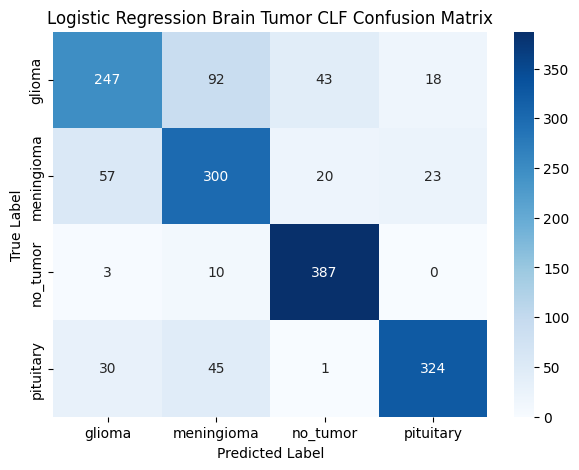

Macro-Averaged ROC-AUC: 0.9192


In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
import pandas as pd

target_names = ['glioma', 'meningioma', 'no_tumor', 'pituitary']
# X_test_reduced = sparse_rnd_proj.transform(X_test)

log_clf = LogisticRegression(max_iter=200)
log_clf.fit(X_train, y_train)
log_preds = log_clf.predict(X_test)

report_dict = classification_report(y_test, log_preds, target_names=target_names, digits=4, output_dict=True)
print("Classification Report")
print(report_dict)

plot_cm(y_test, log_preds, "Logistic Regression")

log_preds = log_clf.predict_proba(X_test)
auc = roc_auc_score(y_test, log_preds, multi_class="ovr", average="macro")
print(f"Macro-Averaged ROC-AUC: {auc:.4f}")

report_dict['roc_auc'] = {'macro_avg_score': auc}
df_report = pd.DataFrame(report_dict).transpose()
output_dir = base_dir / "results" / "logistic_regression_results.csv"

df_report.to_csv(output_dir)

Classification Report
{'glioma': {'precision': 0.9377289377289377, 'recall': 0.64, 'f1-score': 0.7607726597325408, 'support': 400.0}, 'meningioma': {'precision': 0.7831050228310502, 'recall': 0.8575, 'f1-score': 0.8186157517899761, 'support': 400.0}, 'no_tumor': {'precision': 0.8089430894308943, 'recall': 0.995, 'f1-score': 0.8923766816143498, 'support': 400.0}, 'pituitary': {'precision': 0.947103274559194, 'recall': 0.94, 'f1-score': 0.9435382685069009, 'support': 400.0}, 'accuracy': 0.858125, 'macro avg': {'precision': 0.869220081137519, 'recall': 0.858125, 'f1-score': 0.8538258404109419, 'support': 1600.0}, 'weighted avg': {'precision': 0.869220081137519, 'recall': 0.858125, 'f1-score': 0.8538258404109419, 'support': 1600.0}}


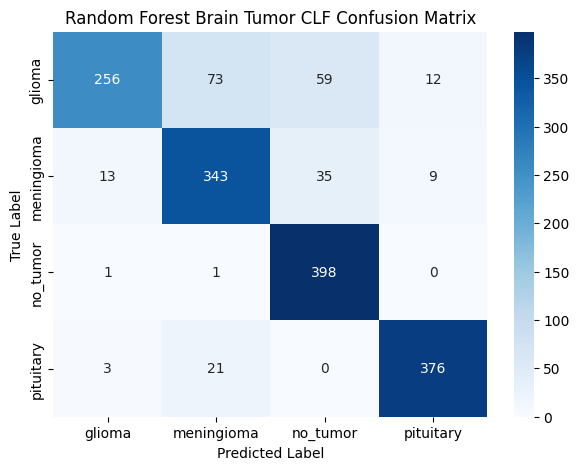

Macro-Averaged ROC-AUC: 0.9620


In [6]:
from sklearn.ensemble import RandomForestClassifier

forest_clf = RandomForestClassifier()
forest_clf.fit(X_train, y_train)
forest_preds = forest_clf.predict(X_test)

report_dict = classification_report(y_test, forest_preds, target_names=target_names, digits=4, output_dict=True)
print("Classification Report")
print(report_dict)

plot_cm(y_test, forest_preds, "Random Forest")

forest_preds = forest_clf.predict_proba(X_test)
auc = roc_auc_score(y_test, forest_preds, multi_class="ovr", average="macro")
print(f"Macro-Averaged ROC-AUC: {auc:.4f}")

report_dict['roc_auc'] = {'macro_avg_score': auc}
df_report = pd.DataFrame(report_dict).transpose()
output_dir = base_dir / "results" / "random_forest_results.csv"

df_report.to_csv(output_dir)

In [8]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)
X_train_reduced = pca.fit_transform(X_train)
X_test_reduced = pca.transform(X_test)

Classification Report
{'glioma': {'precision': 0.8070175438596491, 'recall': 0.69, 'f1-score': 0.7439353099730458, 'support': 400.0}, 'meningioma': {'precision': 0.828042328042328, 'recall': 0.7825, 'f1-score': 0.8046272493573264, 'support': 400.0}, 'no_tumor': {'precision': 0.8814317673378076, 'recall': 0.985, 'f1-score': 0.9303423848878394, 'support': 400.0}, 'pituitary': {'precision': 0.8914549653579676, 'recall': 0.965, 'f1-score': 0.9267707082833133, 'support': 400.0}, 'accuracy': 0.855625, 'macro avg': {'precision': 0.8519866511494382, 'recall': 0.855625, 'f1-score': 0.8514189131253812, 'support': 1600.0}, 'weighted avg': {'precision': 0.8519866511494381, 'recall': 0.855625, 'f1-score': 0.8514189131253813, 'support': 1600.0}}


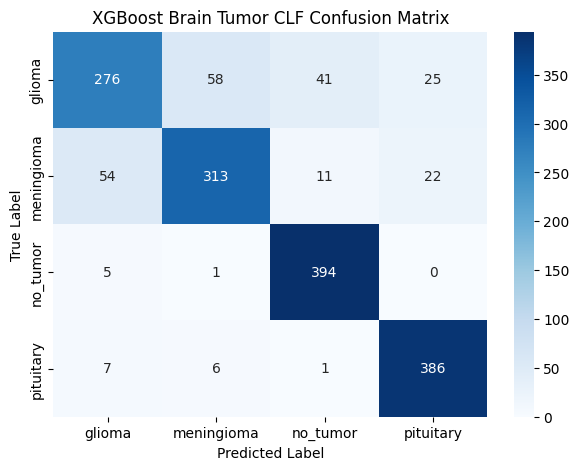

Macro-Averaged ROC-AUC: 0.9639


In [9]:
from xgboost import XGBClassifier

xgb_clf = XGBClassifier(tree_method="hist", objective='multi:softprob', random_state=42, num_class=4)
xgb_clf.fit(X_train_reduced, y_train)
xgb_preds = xgb_clf.predict(X_test_reduced)

report_dict = classification_report(y_test, xgb_preds, target_names=target_names, digits=4, output_dict=True)
print("Classification Report")
print(report_dict)

plot_cm(y_test, xgb_preds, "XGBoost")

xgb_preds = xgb_clf.predict_proba(X_test_reduced)
auc = roc_auc_score(y_test, xgb_preds, multi_class="ovr", average="macro")
print(f"Macro-Averaged ROC-AUC: {auc:.4f}")

report_dict['roc_auc'] = {'macro_avg_score': auc}
df_report = pd.DataFrame(report_dict).transpose()
output_dir = base_dir / "results" / "XGBoost_results.csv"

df_report.to_csv(output_dir)